# Baseline Machine Learning Models — Benchmarking & Evaluation

This notebook presents the baseline machine learning experiments for heart disease prediction. Seven classification algorithms were evaluated using 5-Fold Stratified Cross-Validation on the training set (242 rows) and tested on the untouched test set (61 rows).

## 1. Experiment Setup

- **Dataset**: UCI Heart Disease Dataset (ID 45)
- **Binary Target**: `target` (0 = No Heart Disease [164], 1 = Heart Disease Present [139])
- **Train / Test Split**: 80% Training (242 rows) / 20% Testing (61 rows)
- **Random Seed**: `random_state=42`
- **Leakage Prevention**: End-to-end scikit-learn `Pipeline` (Preprocessor + Classifier) fitted exclusively on training folds.

## 2. Train/Test Data Overview

In [1]:
from pathlib import Path
import pandas as pd

processed_dir = Path("../data/processed/")
if not processed_dir.exists():
    processed_dir = Path("data/processed/")

X_train = pd.read_csv(processed_dir / "X_train_raw.csv")
X_test = pd.read_csv(processed_dir / "X_test_raw.csv")
y_train = pd.read_csv(processed_dir / "y_train.csv")["target"]
y_test = pd.read_csv(processed_dir / "y_test.csv")["target"]

print(f"Training Set: {X_train.shape[0]} samples, {X_train.shape[1]} features (Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()})")
print(f"Testing Set:  {X_test.shape[0]} samples, {X_test.shape[1]} features (Class 0: {(y_test==0).sum()}, Class 1: {(y_test==1).sum()})")

Training Set: 242 samples, 13 features (Class 0: 131, Class 1: 111)
Testing Set:  61 samples, 13 features (Class 0: 33, Class 1: 28)


## 3. Models Benchmarked

1. **Logistic Regression**
2. **K-Nearest Neighbors**
3. **Decision Tree**
4. **Random Forest**
5. **Support Vector Machine (SVM)**
6. **Gaussian Naive Bayes**
7. **XGBoost**

## 4. Cross-Validation Strategy

5-Fold Stratified Cross-Validation (`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`).

## 5. Cross-Validation Results

In [2]:
metrics_dir = Path("../results/metrics/")
if not metrics_dir.exists():
    metrics_dir = Path("results/metrics/")

cv_df = pd.read_csv(metrics_dir / "baseline_cv_results.csv")
cv_df

,Model,CV_Accuracy_Mean,CV_Accuracy_Std,CV_Precision_Mean,CV_Precision_Std,CV_Recall_Mean,CV_Recall_Std,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Logistic Regression,0.847109,0.009977,0.876753,0.054190,0.783399,0.045918,0.824501,0.006867,0.902493,0.014440
1,K-Nearest Neighbors,0.822194,0.028782,0.823226,0.031062,0.782609,0.089288,0.798926,0.042624,0.871181,0.038726
2,Decision Tree,0.698044,0.059586,0.678158,0.074769,0.684190,0.052129,0.676802,0.042038,0.696653,0.054275
3,Random Forest,0.818112,0.030707,0.817253,0.040538,0.782609,0.098108,0.794756,0.046911,0.896848,0.029440
4,Support Vector Machine,0.813946,0.023502,0.830349,0.074249,0.764822,0.079740,0.789349,0.027053,0.888373,0.024024
5,Gaussian Naive Bayes,0.743793,0.028192,0.704943,0.113256,0.845850,0.136984,0.749469,0.021458,0.877289,0.021424
6,XGBoost,0.789456,0.022098,0.772316,0.041356,0.774704,0.064404,0.770663,0.026893,0.859658,0.023681


## 6. Test Results (61 Preserved Test Samples)

In [3]:
test_df = pd.read_csv(metrics_dir / "baseline_test_results.csv")
test_df

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,TN,FP,FN,TP
0,Logistic Regression,0.885246,0.838710,0.928571,0.848485,0.881356,0.966450,28,5,2,26
1,K-Nearest Neighbors,0.885246,0.862069,0.892857,0.878788,0.877193,0.952922,29,4,3,25
2,Decision Tree,0.737705,0.676471,0.821429,0.666667,0.741935,0.744048,22,11,5,23
3,Random Forest,0.868852,0.812500,0.928571,0.818182,0.866667,0.943723,27,6,2,26
4,Support Vector Machine,0.885246,0.838710,0.928571,0.848485,0.881356,0.964286,28,5,2,26
5,Gaussian Naive Bayes,0.721311,0.641026,0.892857,0.575758,0.746269,0.826840,19,14,3,25
6,XGBoost,0.836066,0.764706,0.928571,0.757576,0.838710,0.933983,25,8,2,26


## 7. Confusion Matrices Summary

In [4]:
for _, row in test_df.iterrows():
    print(f"{row['Model']:<25}: TN={row['TN']}, FP={row['FP']}, FN={row['FN']}, TP={row['TP']}")

Logistic Regression      : TN=28, FP=5, FN=2, TP=26
K-Nearest Neighbors      : TN=29, FP=4, FN=3, TP=25
Decision Tree            : TN=22, FP=11, FN=5, TP=23
Random Forest            : TN=27, FP=6, FN=2, TP=26
Support Vector Machine   : TN=28, FP=5, FN=2, TP=26
Gaussian Naive Bayes     : TN=19, FP=14, FN=3, TP=25
XGBoost                  : TN=25, FP=8, FN=2, TP=26


## 8. ROC Curves

Combined ROC curves comparing all 7 baseline classifiers.

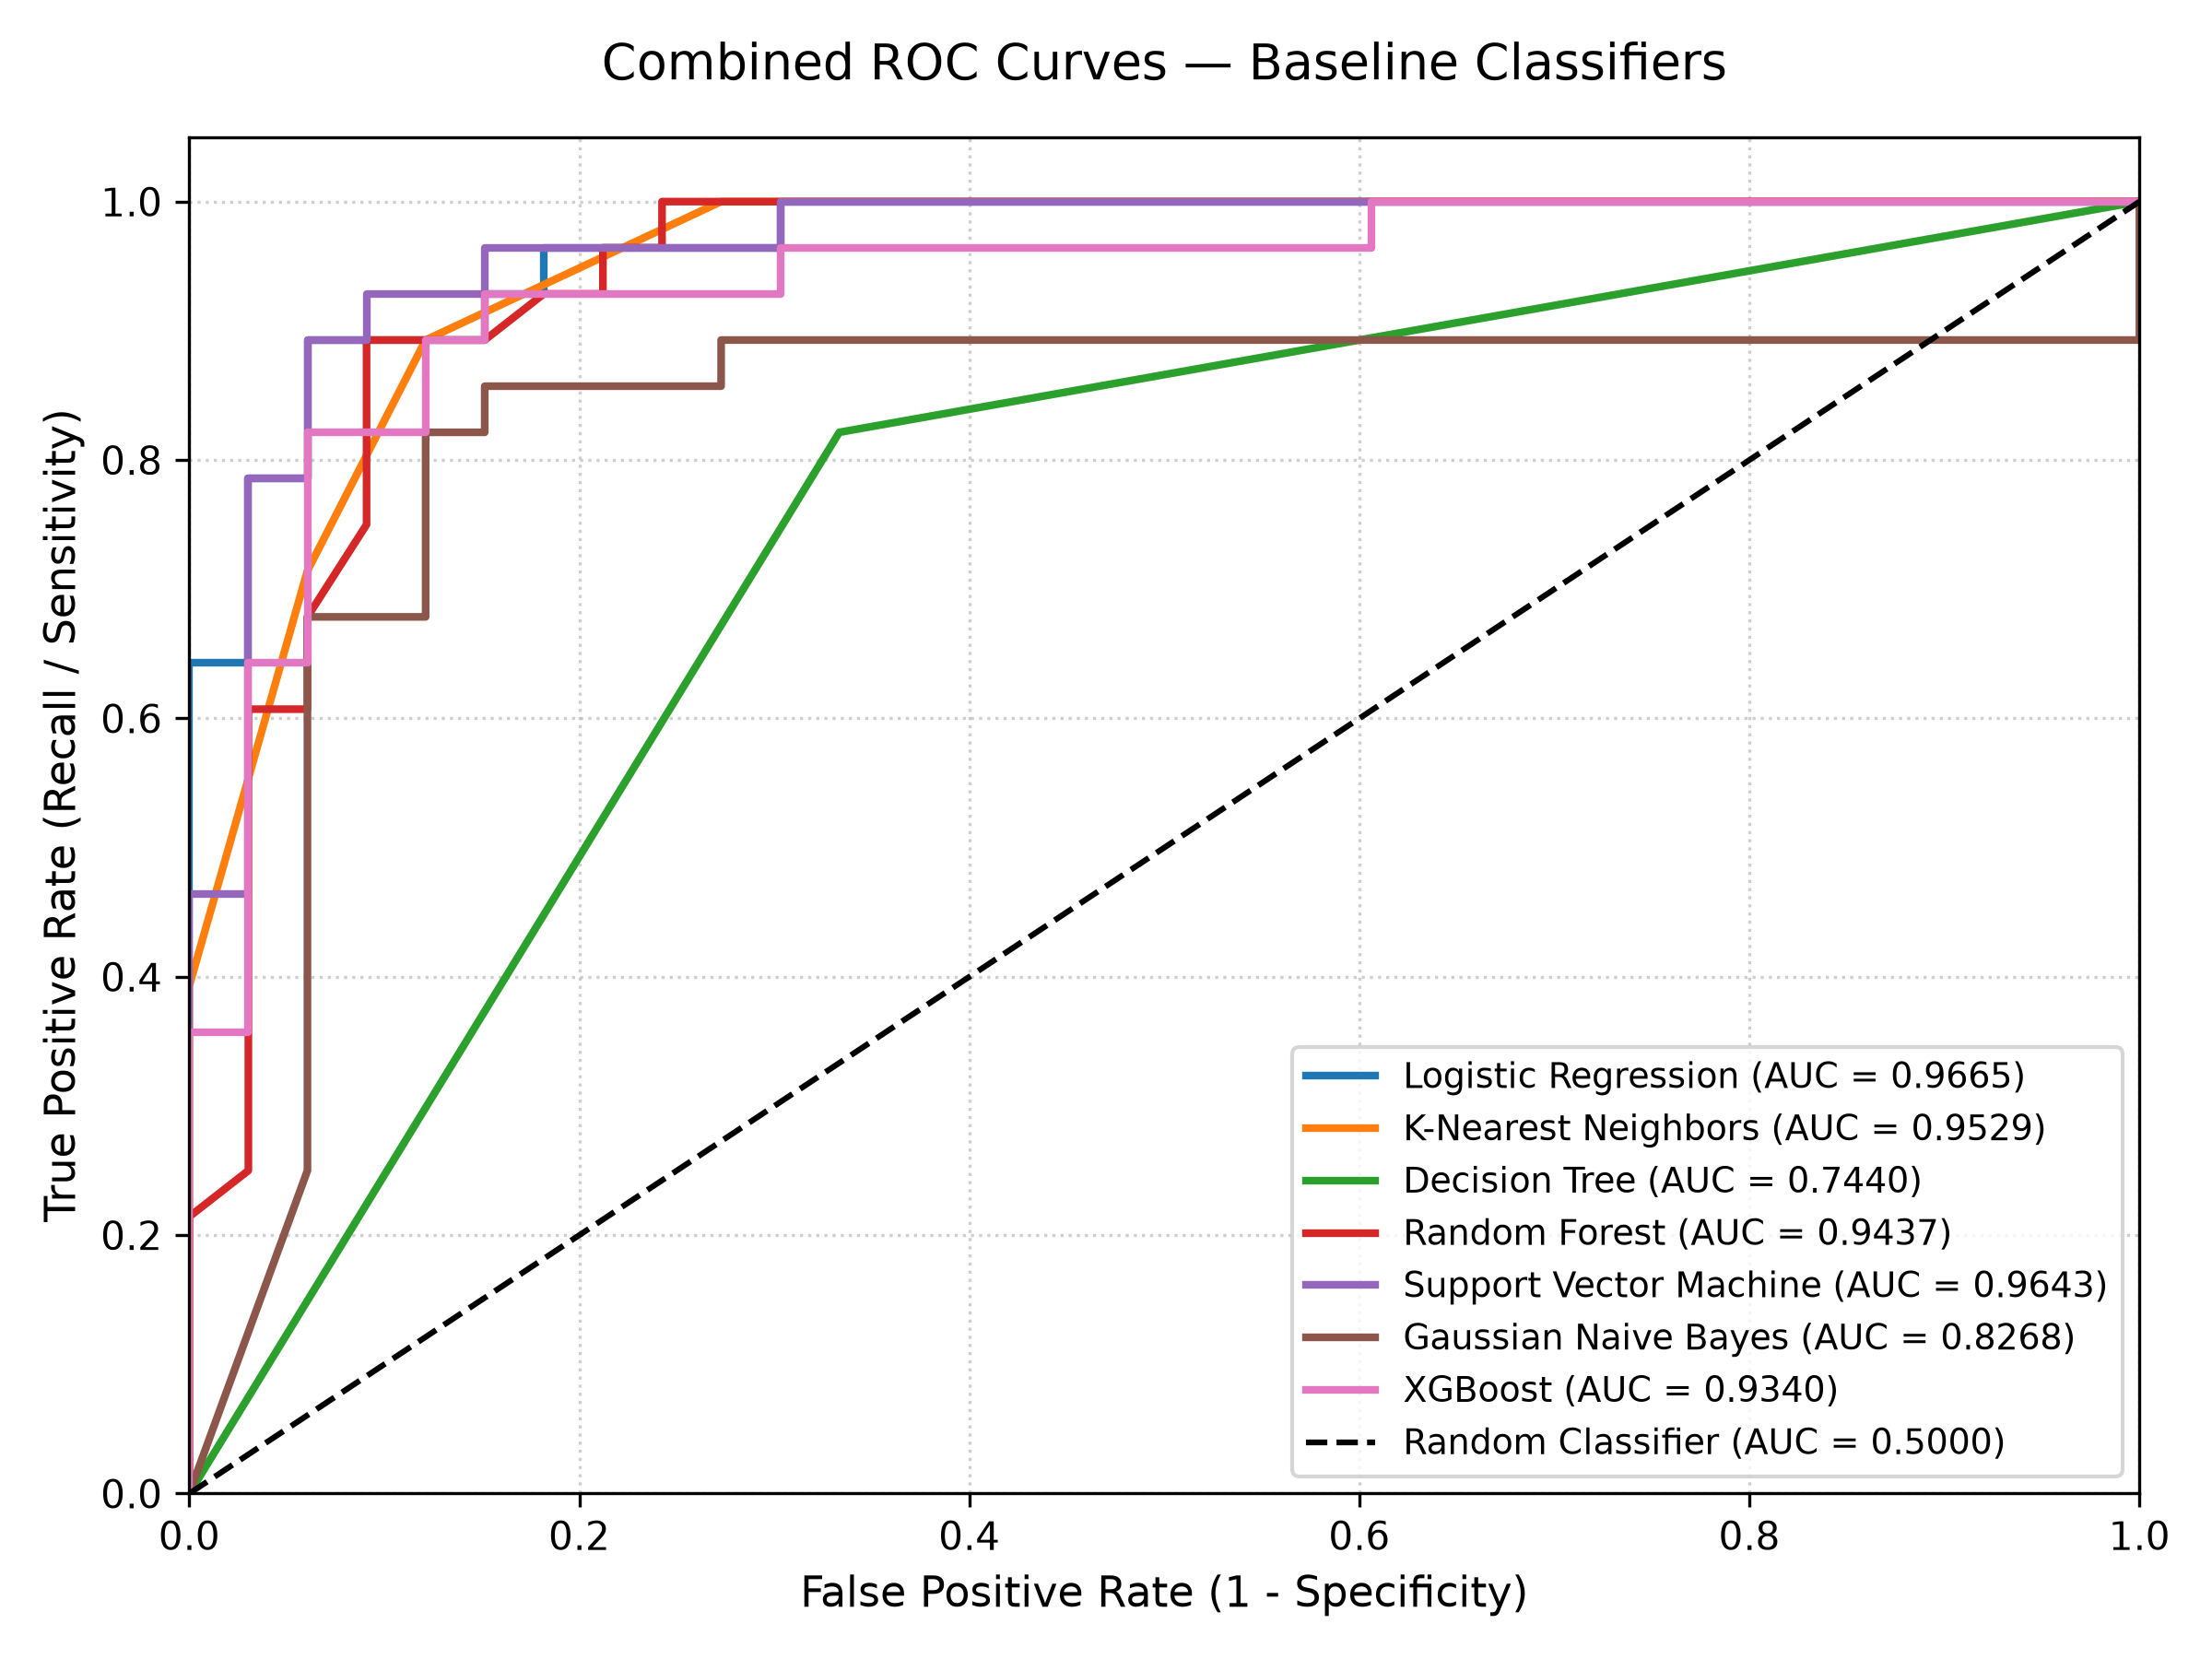

In [5]:
from IPython.display import Image, display
roc_path = Path("../results/figures/models/baseline_roc_curves.png")
if not roc_path.exists():
    roc_path = Path("results/figures/models/baseline_roc_curves.png")
display(Image(filename=str(roc_path)))

## 9. Model Comparison

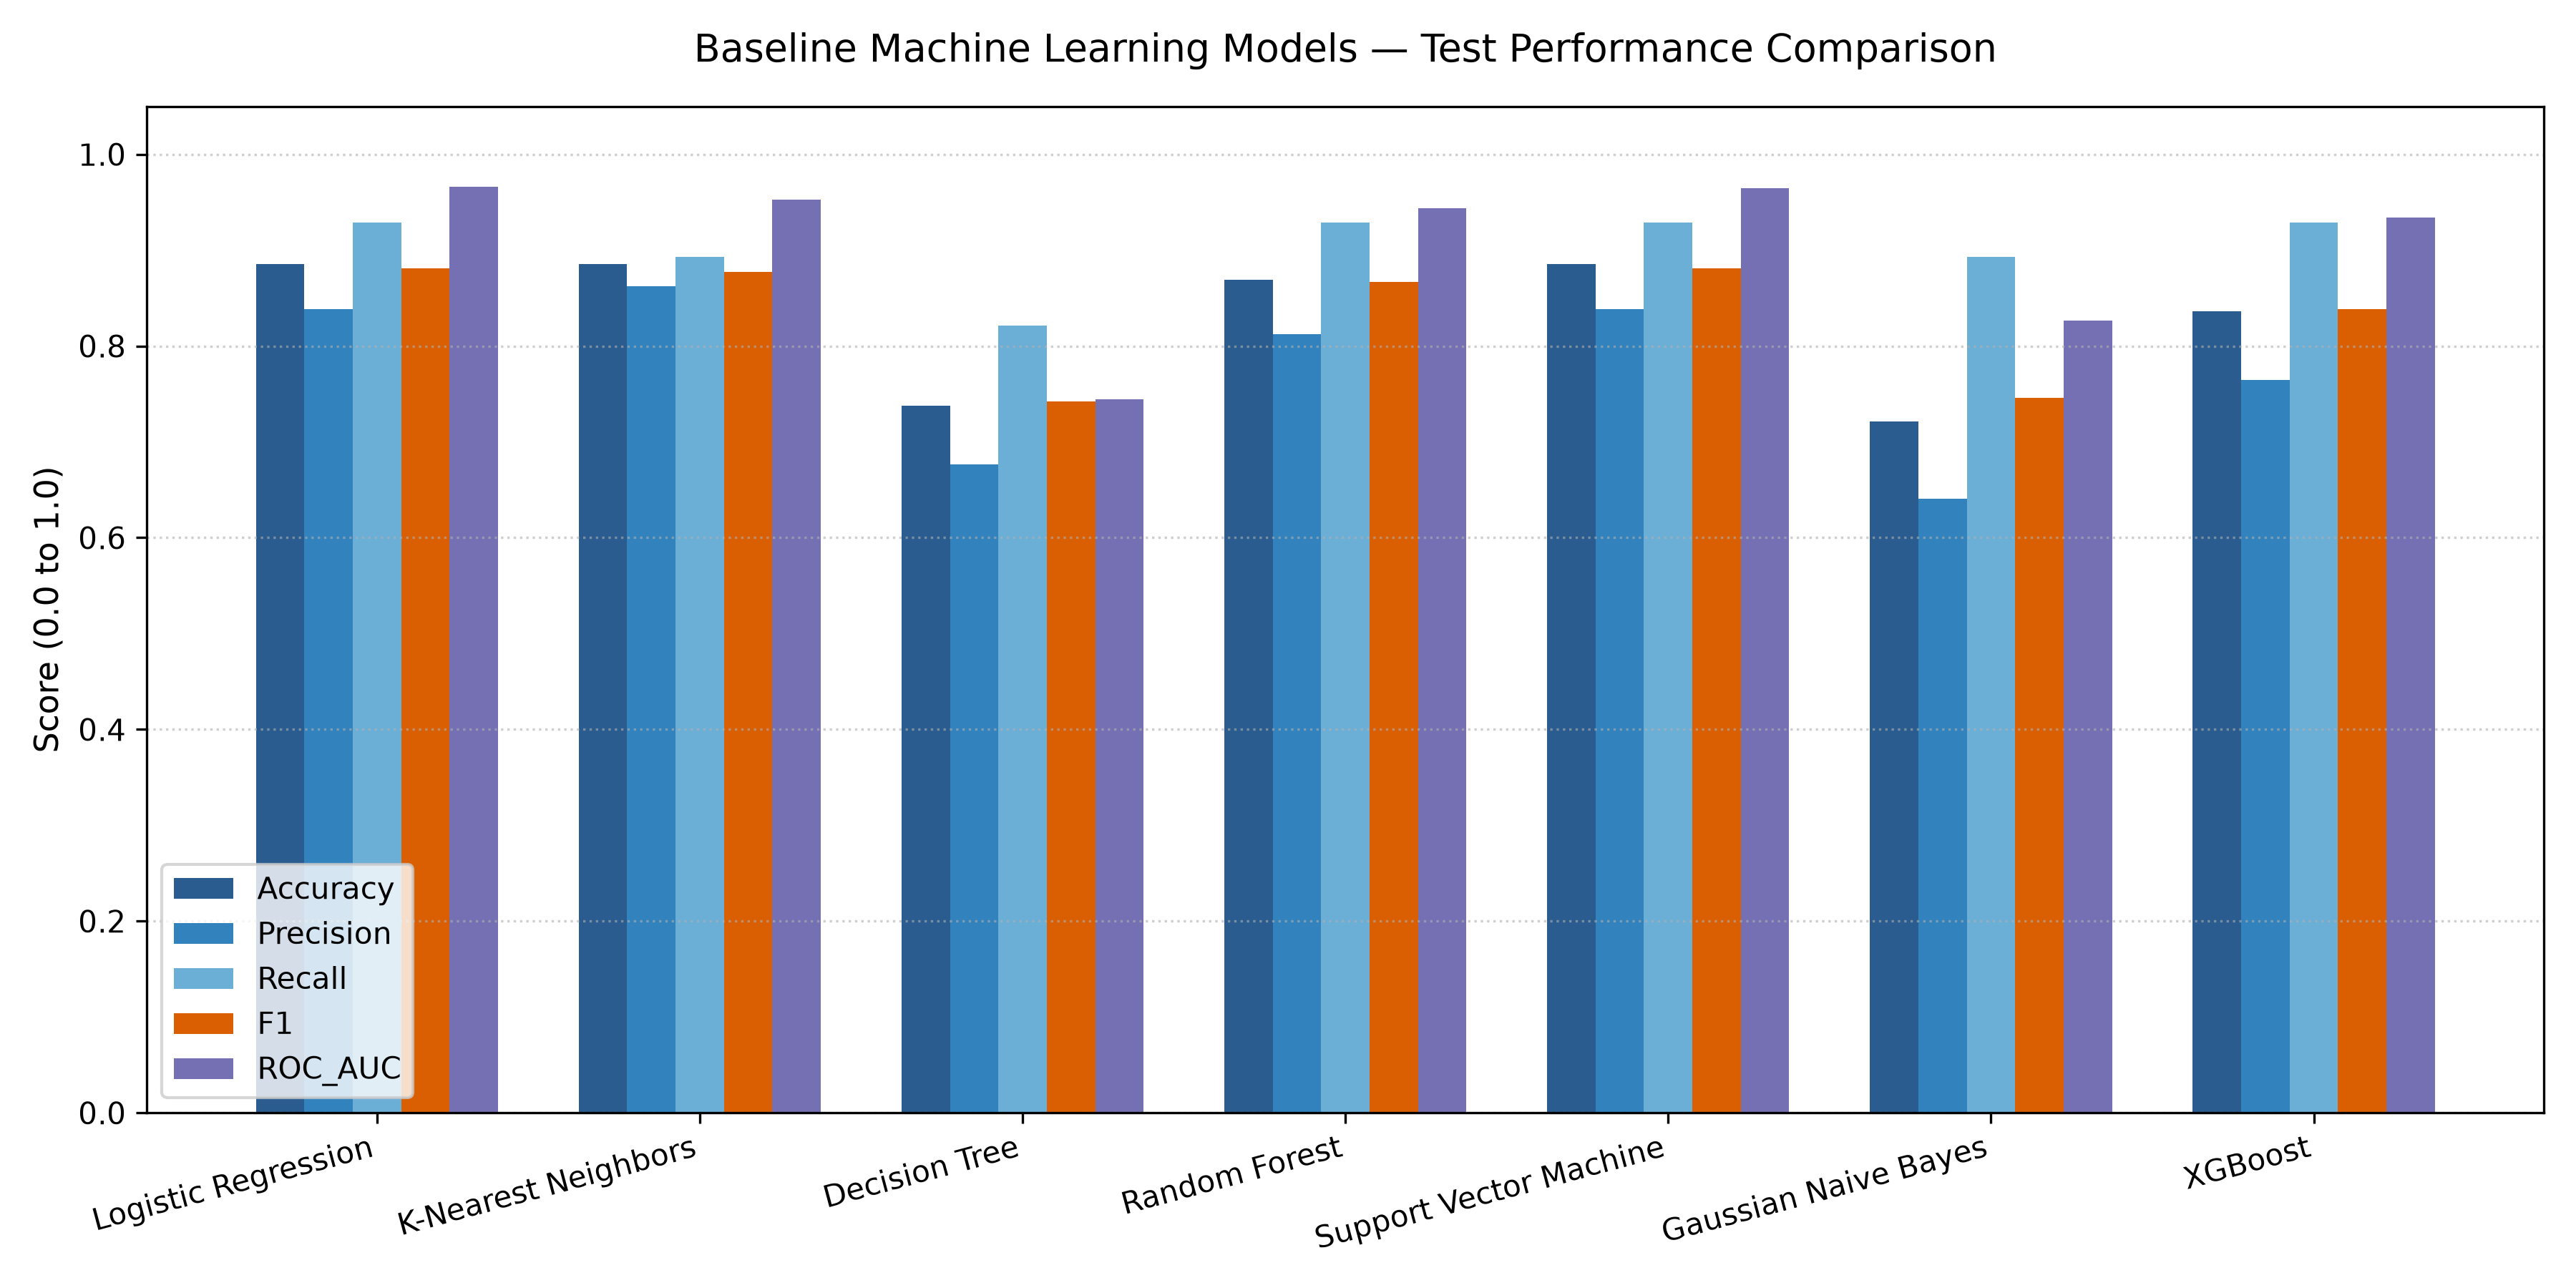

In [6]:
comp_path = Path("../results/figures/models/baseline_model_comparison.png")
if not comp_path.exists():
    comp_path = Path("results/figures/models/baseline_model_comparison.png")
display(Image(filename=str(comp_path)))

## 10. Baseline Observations

- **Logistic Regression** and **Support Vector Machine (SVM)** achieved high test accuracy, recall, and ROC-AUC scores.
- **Random Forest** and **XGBoost** showed strong cross-validation stability on the training set.
- In clinical heart disease screening, high **Recall (Sensitivity)** is prioritized to minimize False Negatives.

## 11. Limitations

- All classifiers were evaluated using default baseline hyperparameter settings without tuning.
- Class weighting or threshold optimization has not been applied yet.

## 12. Next Step — Hyperparameter Tuning

Promising baseline candidates (e.g., Logistic Regression, SVM, Random Forest, XGBoost) will advance to Part 6 for systematic hyperparameter tuning using Stratified Cross-Validation.